# **MEDICAL INSURANCE COST ANALYSIS & PREDICTION SYSTEM**

### **INSTALL REQUIRED LIBRARIES**

In [5]:
!pip install plotly -q

### **IMPORT LIBRARIES**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import plotly.express as px


### **CONNECT GOOGLE DRIVE**

In [7]:
drive.mount('/content/drive')

Mounted at /content/drive


### **LOAD DATASET**

In [9]:
file_path = "/content/drive/MyDrive/Colab Notebooks/insurance.csv"
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully")
print("Dataset Shape :", df.shape)
display(df.head())

Dataset Loaded Successfully
Dataset Shape : (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **DATASET INFORMATION**

In [11]:
print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()



Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows
0


### **DESCRIPTIVE STATISTICS**

In [12]:
print("\nSummary Statistics")
display(df.describe())
print("\nAverage Age :", df["age"].mean())
print("Average BMI :", df["bmi"].mean())
print("Average Children :", df["children"].mean())
print("Average Charges :", df["charges"].mean())


Summary Statistics


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010



Average Age : 39.222139117427076
Average BMI : 30.66345175766642
Average Children : 1.0957367240089753
Average Charges : 13279.121486655948


### **EXPLORATORY DATA ANALYSIS**

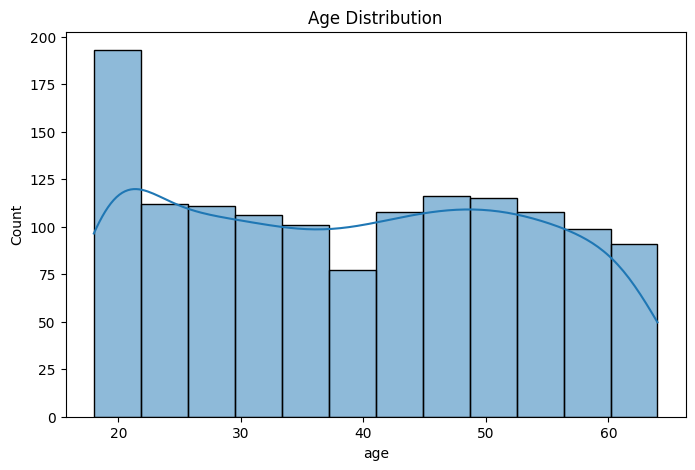

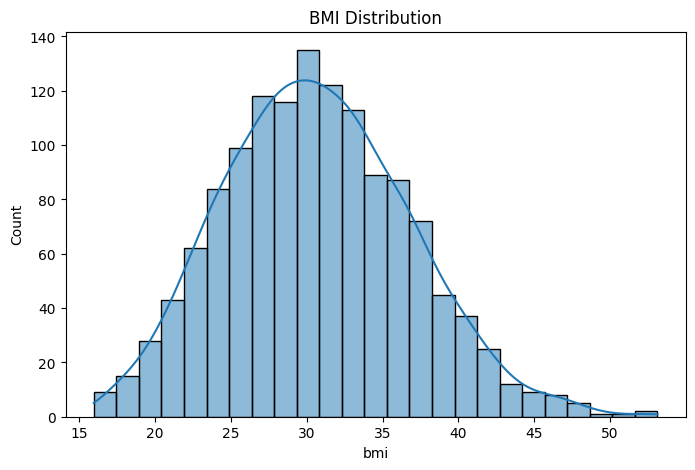

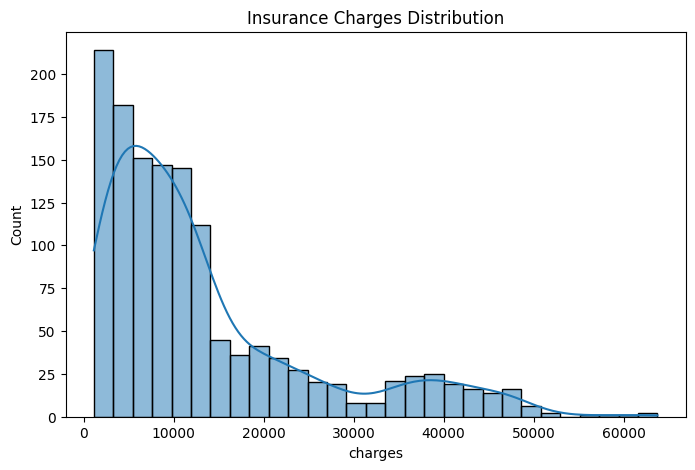

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.title("BMI Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()


### **INSURANCE COST ANALYSIS**

In [14]:
print("\nAverage Charges by Gender")
print(df.groupby("sex")["charges"].mean())

print("\nAverage Charges by Smoker")
print(df.groupby("smoker")["charges"].mean())

print("\nAverage Charges by Region")
print(df.groupby("region")["charges"].mean())

print("\nAverage Charges by Children")
print(df.groupby("children")["charges"].mean())


Average Charges by Gender
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

Average Charges by Smoker
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Average Charges by Region
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Average Charges by Children
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


### **AGE GROUP ANALYSIS**

In [15]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0,20,40,60,100],
    labels=["Teen","Adult","Middle Age","Senior"]
)

print("\nAge Group Charges")
print(df.groupby("Age_Group")["charges"].mean())


Age Group Charges
Age_Group
Teen           8756.354651
Adult         10686.686643
Middle Age    15888.757668
Senior        21063.163398
Name: charges, dtype: float64


/tmp/ipykernel_949/1147867050.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Age_Group")["charges"].mean())


### **BMI CATEGORY ANALYSIS**

In [16]:
df["BMI_Category"] = pd.cut(
    df["bmi"],
    bins=[0,18.5,25,30,100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

print("\nBMI Category Charges")
print(df.groupby("BMI_Category")["charges"].mean())


BMI Category Charges
BMI_Category
Underweight     8657.620652
Normal         10435.440719
Overweight     10997.803881
Obese          15580.700985
Name: charges, dtype: float64


/tmp/ipykernel_949/22850570.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("BMI_Category")["charges"].mean())


### **VISUALIZATION**

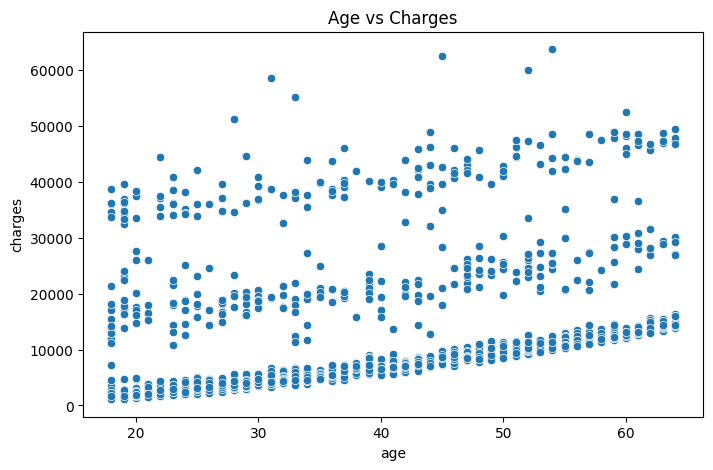

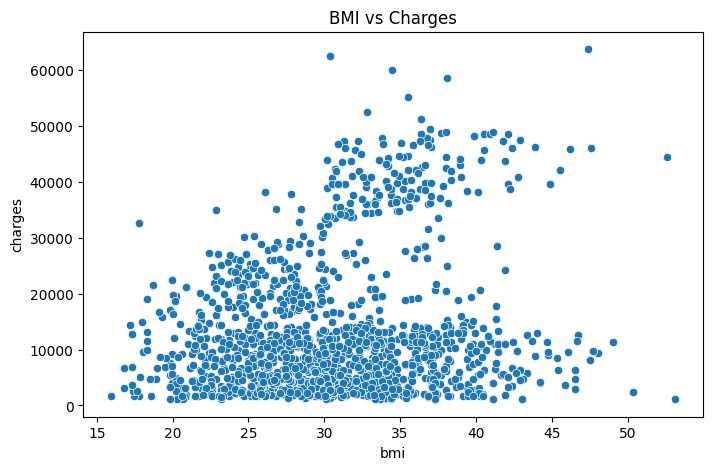

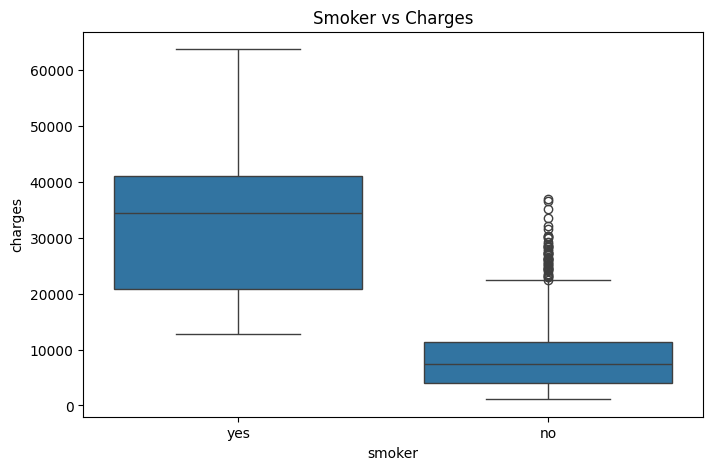

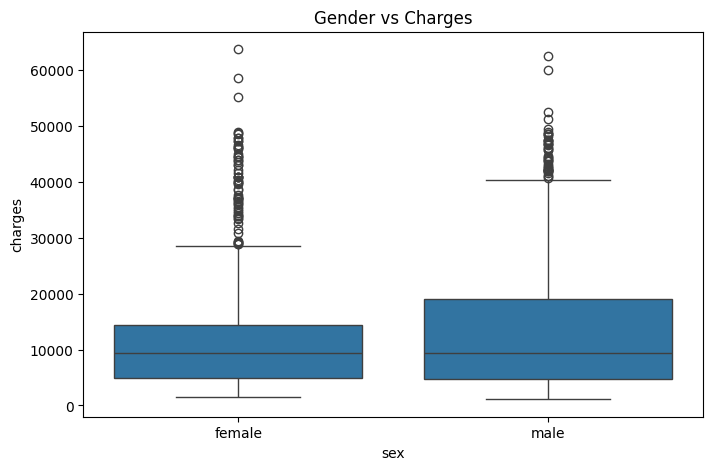

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="age",y="charges")
plt.title("Age vs Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="bmi",y="charges")
plt.title("BMI vs Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="smoker",y="charges")
plt.title("Smoker vs Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="sex",y="charges")
plt.title("Gender vs Charges")
plt.show()

### **PIE CHARTS**

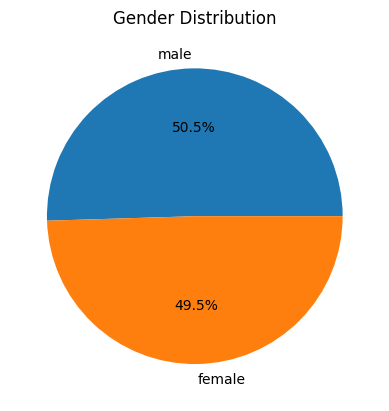

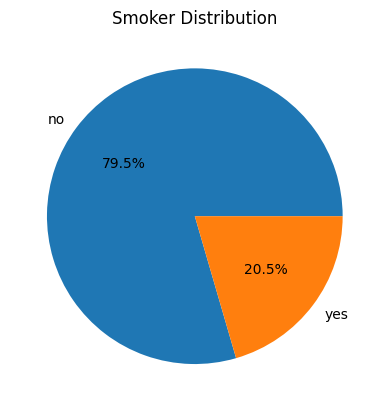

In [18]:
df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

df["smoker"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Smoker Distribution")
plt.ylabel("")
plt.show()

### **ENCODING**

In [19]:
data = df.copy()

le = LabelEncoder()

data["sex"] = le.fit_transform(data["sex"])
data["smoker"] = le.fit_transform(data["smoker"])
data["region"] = le.fit_transform(data["region"])

### **CORRELATION HEATMAP**

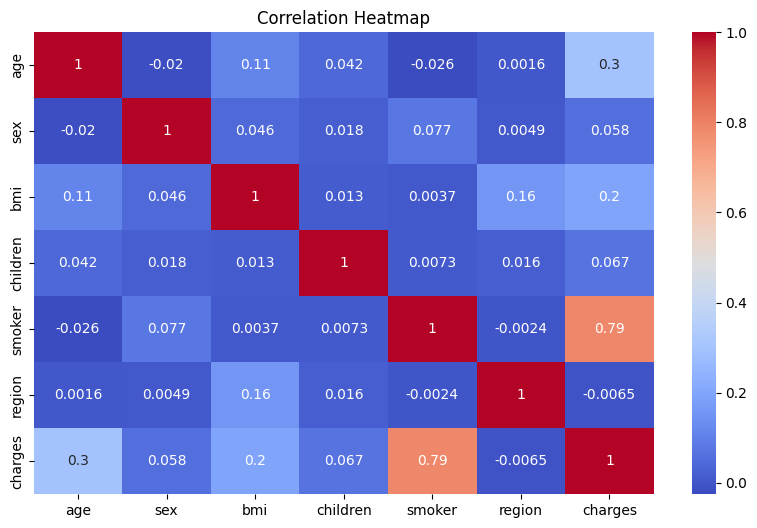

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


### **RISK ANALYSIS**

In [21]:
low = data["charges"].quantile(0.33)
high = data["charges"].quantile(0.66)

def risk_category(x):

    if x <= low:
        return "Low Risk"

    elif x <= high:
        return "Medium Risk"

    else:
        return "High Risk"

data["Risk_Category"] = data["charges"].apply(risk_category)

print("\nRisk Category Count")
print(data["Risk_Category"].value_counts())



Risk Category Count
Risk_Category
High Risk      455
Low Risk       441
Medium Risk    441
Name: count, dtype: int64


### **SIMPLE LINEAR REGRESSION**

In [22]:
print("\n==============================")
print("SIMPLE LINEAR REGRESSION")
print("==============================")

X = data[["age"]]
y = data["charges"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2 Score :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))


SIMPLE LINEAR REGRESSION
R2 Score : 0.09513000782072023
MAE : 9657.78934976123
RMSE : 12894.779883028823


### **MULTIPLE LINEAR REGRESSION**

In [23]:
print("\n==============================")
print("MULTIPLE LINEAR REGRESSION")
print("==============================")

X = data[["age","bmi","children","smoker"]]
y = data["charges"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

mlr = LinearRegression()

mlr.fit(X_train,y_train)

pred = mlr.predict(X_test)

print("R2 Score :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))


MULTIPLE LINEAR REGRESSION
R2 Score : 0.8045531086669288
MAE : 4198.592612356366
RMSE : 5992.875059638206


### **LOGISTIC REGRESSION**


LOGISTIC REGRESSION
Accuracy : 0.9104477611940298
Precision : 0.9
Recall : 0.9264705882352942
F1 Score : 0.9130434782608695

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       132
           1       0.90      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



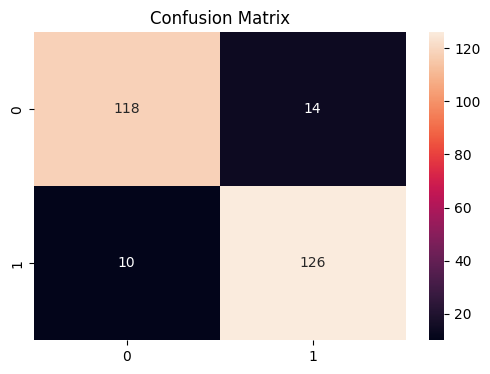

In [24]:
print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

median_charge = data["charges"].median()

data["Insurance_Class"] = np.where(
    data["charges"] > median_charge,
    1,
    0
)

X = data[["age","bmi","children","smoker"]]
y = data["Insurance_Class"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()

log_model.fit(X_train,y_train)

pred = log_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision :", precision_score(y_test,pred))
print("Recall :", recall_score(y_test,pred))
print("F1 Score :", f1_score(y_test,pred))

print("\nClassification Report")
print(classification_report(y_test,pred))

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()


### **RANDOM FOREST REGRESSOR**

In [25]:
print("\n==============================")
print("RANDOM FOREST REGRESSOR")
print("==============================")

X = data[["age","bmi","children","smoker"]]
y = data["charges"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print("R2 Score :", r2_score(y_test,rf_pred))
print("MAE :", mean_absolute_error(y_test,rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,rf_pred)))


RANDOM FOREST REGRESSOR
R2 Score : 0.8725194979350843
MAE : 2703.82427869403
RMSE : 4839.970588901563


### **FEATURE IMPORTANCE**

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
display(importance)


Feature Importance


,Feature,Importance
3,smoker,0.599300
1,bmi,0.234739
0,age,0.140489
2,children,0.025472


### **PLOTLY DASHBOARD**

In [27]:
fig = px.histogram(
    df,
    x="charges",
    title="Insurance Charges Distribution"
)
fig.show()

fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker",
    title="Age vs Charges"
)
fig.show()

fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker",
    title="BMI vs Charges"
)
fig.show()

### **USER PREDICTION**

In [28]:
print("\n==============================")
print("INSURANCE COST PREDICTION")
print("==============================")

age = float(input("Enter Age : "))
bmi = float(input("Enter BMI : "))
children = int(input("Enter Number of Children : "))
smoker = int(input("Smoker (1=Yes,0=No) : "))

sample = pd.DataFrame({
    "age":[age],
    "bmi":[bmi],
    "children":[children],
    "smoker":[smoker]
})

prediction = rf.predict(sample)

print("\nPredicted Insurance Charge = ₹",
      round(prediction[0],2))



INSURANCE COST PREDICTION
Enter Age : 18
Enter BMI : 9
Enter Number of Children : 1
Smoker (1=Yes,0=No) : 0

Predicted Insurance Charge = ₹ 3325.32


### **END**

In [29]:
print("\nPROJECT COMPLETED SUCCESSFULLY")


PROJECT COMPLETED SUCCESSFULLY
